In [ ]:
import pandas as pd

# Load datasets
df = pd.read_csv('/content/marketing_campaign_data.csv')
dict_df = pd.read_csv('/content/marketing_data_dictionary.csv')

# Show first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dataset basic information
print(df.info())

# Missing values check
print(df.isnull().sum())

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,5.600000e+04,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,...,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,8.389352e+06,1971.666696,57252.189521,0.539911,0.362143,63.221107,246.981482,16.152661,268.294018,51.097732,...,2.110750,4.706411,5.170107,0.062393,0.056821,0.045661,0.134446,0.014411,0.147589,0.007625
std,4.844638e+06,12.211066,34307.247999,0.521349,0.510567,31.157066,358.569481,33.931463,342.165712,73.226860,...,2.357824,2.896366,2.555911,0.241870,0.231503,0.208750,0.341134,0.119178,0.354696,0.086988
min,3.600000e+01,1936.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.187372e+06,1963.000000,28252.025000,0.000000,0.000000,35.000000,0.000000,0.000000,42.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.383784e+06,1973.000000,58838.550000,1.000000,0.000000,71.000000,64.000000,0.000000,107.000000,13.000000,...,1.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.258576e+07,1981.000000,86930.650000,1.000000,1.000000,93.000000,353.000000,15.000000,363.000000,71.000000,...,3.000000,6.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.677716e+07,1996.000000,258027.500000,2.000000,2.000000,99.000000,1493.000000,199.000000,1341.000000,259.000000,...,14.000000,13.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Create Age column
df['Age'] = 2025 - df['Year_Birth']

In [ ]:
# Total Spend
df['Total_Spend'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Total Children
df['children'] = df['Kidhome'] + df['Teenhome']

# Total Purchases
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Show result
df[['Age', 'Total_Spend', 'children', 'Total_Purchases']].head()

,Age,Total_Spend,children,Total_Purchases
0,40,69,1,10
1,50,39,2,3
2,47,1512,0,9
3,49,478,1,15
4,44,330,2,8


In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'children', 'Total_Purchases'],
      dtype='object')

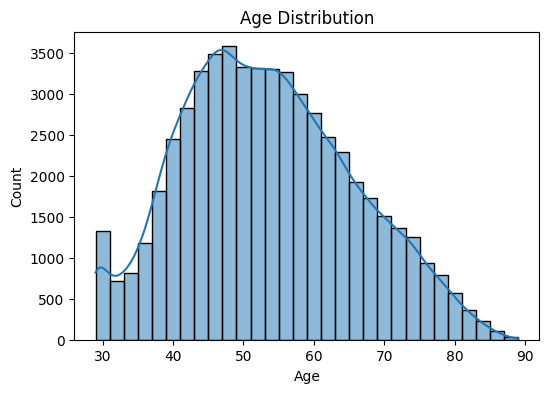

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

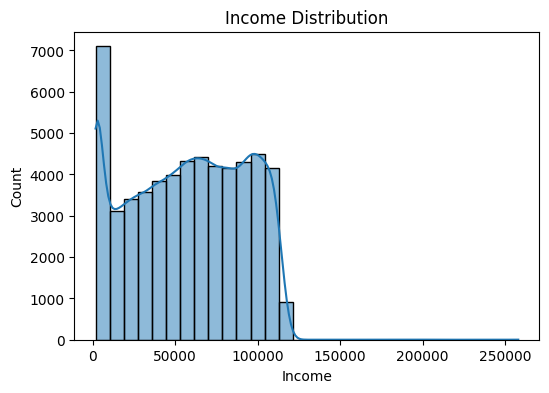

In [ ]:
# Income Disribution
plt.figure(figsize=(6,4))
sns.histplot(df['Income'],bins=30, kde=True)
plt.title('Income Distribution')
plt.show()

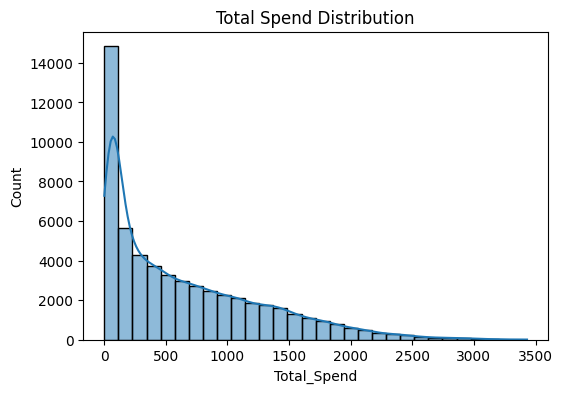

In [ ]:
# Total Spend Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Total_Spend'], bins=30,kde=True)
plt.title('Total Spend Distribution')
plt.show()

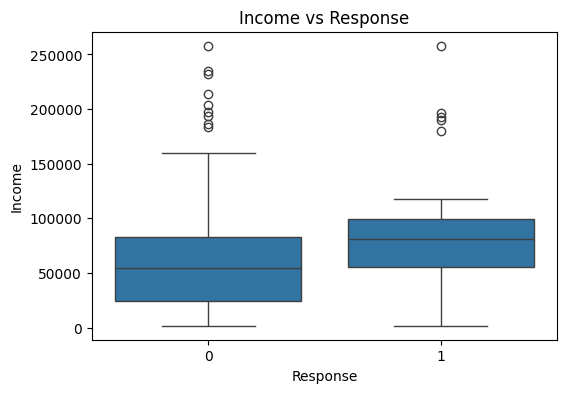

In [ ]:
# Income vs Response
plt.figure(figsize=(6,4))
sns.boxplot(x='Response', y='Income', data=df)
plt.title('Income vs Response')
plt.show()

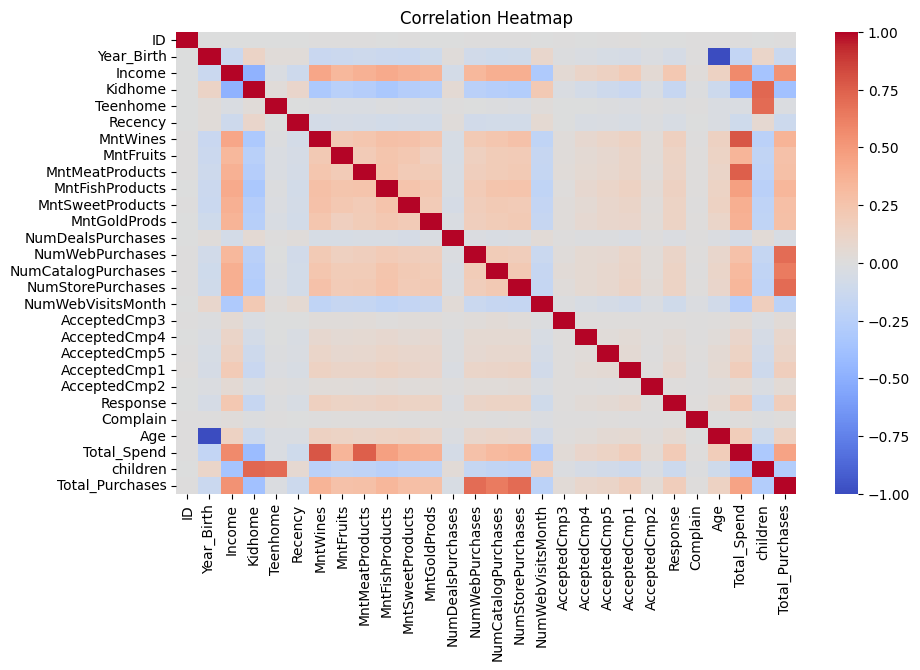

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Customer Segmentation

def segment_customer(spend):
  if spend < 300:
    return 'Low Spender'
  elif spend < 1000:
      return 'Medium Value'
  else:
      return 'High Vallue'

df['Customer_Segment'] = df['Total_Spend'].apply(segment_customer)

# Count customers in each segment
print(df['Customer_Segment'].value_counts())

Customer_Segment
Low Spender     23226
Medium Value    18370
High Vallue     14404
Name: count, dtype: int64


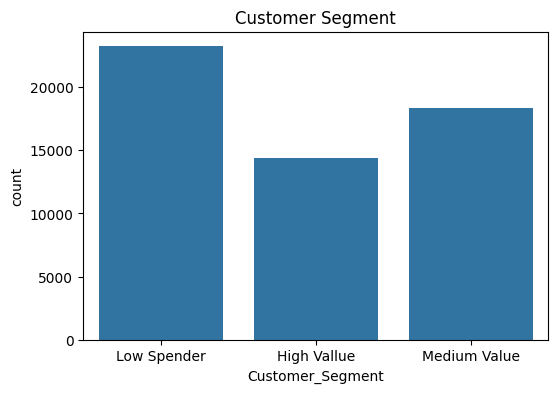

In [ ]:
# Customer Segment Visualization

plt.figure(figsize=(6,4))

sns.countplot(x='Customer_Segment', data=df)

plt.title('Customer Segment')
plt.show()

In [ ]:
# Average spending by customer segment

df.groupby('Customer_Segment')['Total_Spend'].mean()

,Total_Spend
Customer_Segment,
High Vallue,1535.930714
Low Spender,106.238999
Medium Value,613.374143


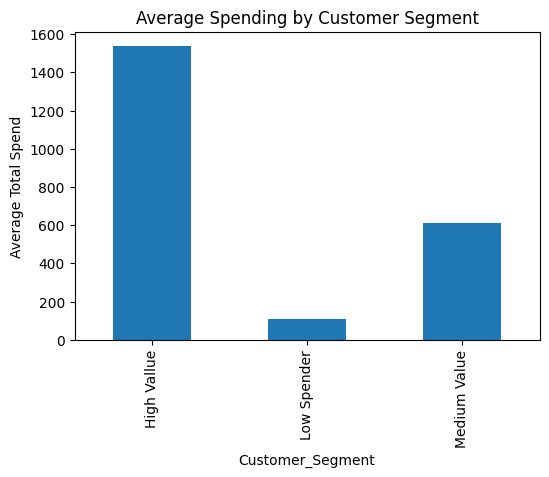

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Total_Spend'].mean().plot(kind='bar')

plt.title('Average Spending by Customer Segment')
plt.ylabel('Average Total Spend')
plt.show()

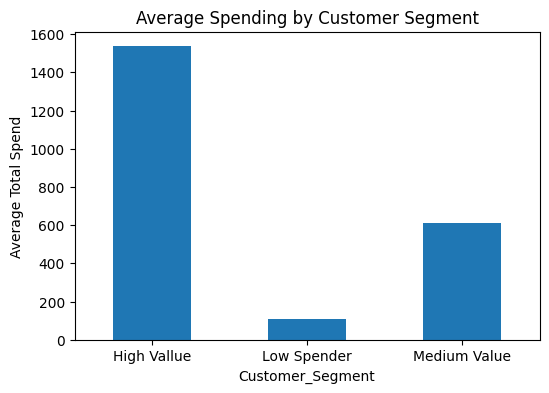

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Total_Spend'].mean().plot(kind='bar')

plt.title('Average Spending by Customer Segment')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=0) # labels straight ho jayenge
plt.show()

In [ ]:
# Customer segment summary

segment_summary = df.groupby('Customer_Segment')[[
    'Income',
    'Total_Spend',
    'Total_Purchases',
    'children'
]].mean()

print(segment_summary)

                        Income  Total_Spend  Total_Purchases  children
Customer_Segment                                                      
High Vallue       81479.366169  1535.930714        14.141419  0.606082
Low Spender       33289.650030   106.238999         7.961767  1.180186
Medium Value      68552.444818   613.374143        12.579532  0.782471


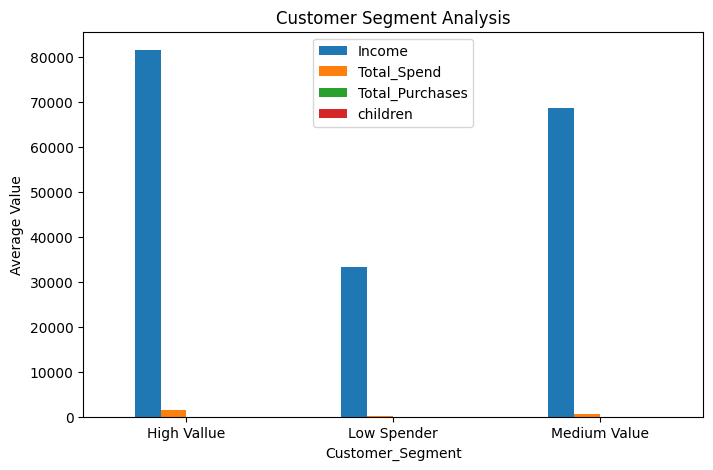

In [ ]:
segment_summary.plot(kind='bar', figsize=(8,5))

plt.title('Customer Segment Analysis')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.show()

<Figure size 600x400 with 0 Axes>

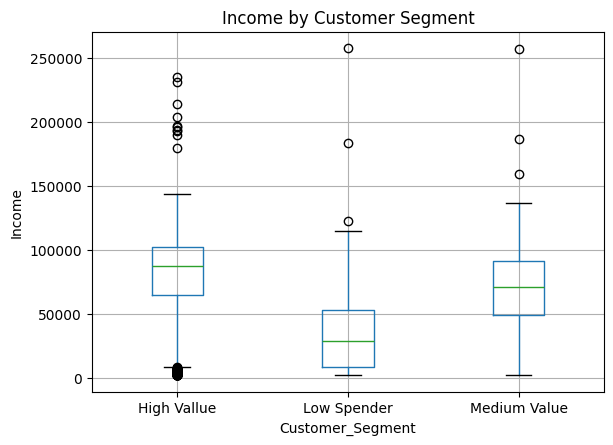

In [ ]:
plt.figure(figsize=(6,4))

df.boxplot(column='Income', by='Customer_Segment')

plt.title('Income by Customer Segment')
plt.suptitle('')
plt.ylabel('Income')

plt.show()

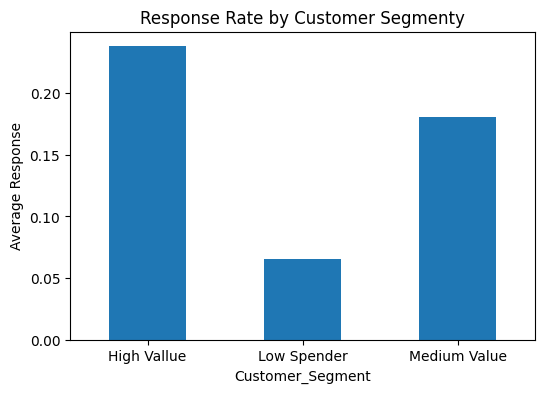

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Response'].mean().plot(kind='bar')

plt.title('Response Rate by Customer Segmenty')
plt.ylabel('Average Response')
plt.xticks(rotation=0)

plt.show()

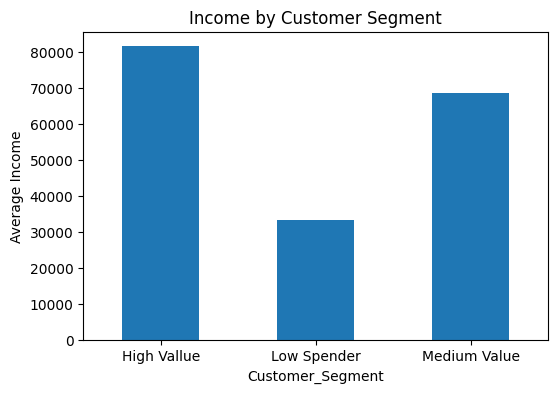

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Income'].mean().plot(kind='bar')

plt.title('Income by Customer Segment')
plt.ylabel('Average Income')
plt.xticks(rotation=0)

plt.show()

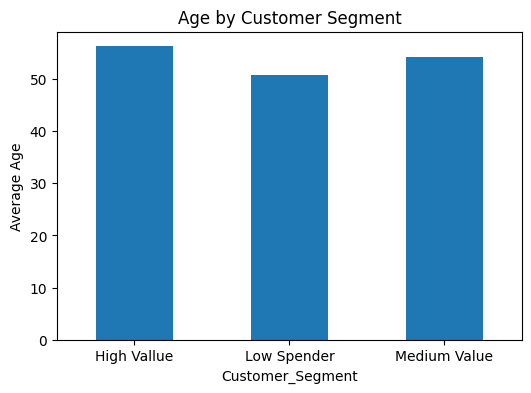

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Age'].mean().plot(kind='bar')

plt.title('Age by Customer Segment')
plt.ylabel('Average Age')
plt.xticks(rotation=0)

plt.show()

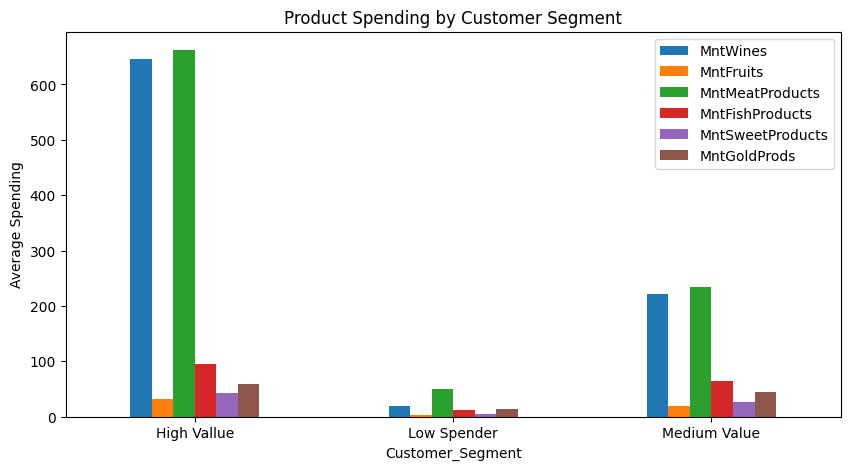

In [ ]:
product_spend = df.groupby('Customer_Segment')[
    ['MntWines',
     'MntFruits',
     'MntMeatProducts',
     'MntFishProducts',
     'MntSweetProducts',
     'MntGoldProds']
].mean()

product_spend.plot(kind='bar', figsize=(10,5))

plt.title('Product Spending by Customer Segment')
plt.ylabel('Average Spending')
plt.xticks(rotation=0)

plt.show()

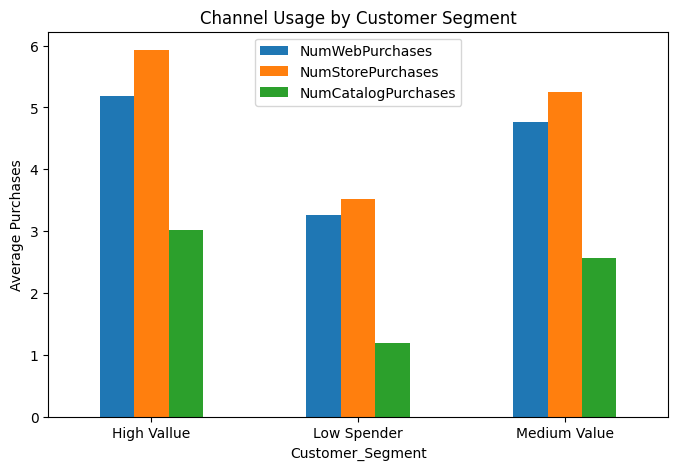

In [ ]:
channel_usage = df.groupby('Customer_Segment')[
    ['NumWebPurchases',
     'NumStorePurchases',
     'NumCatalogPurchases']
].mean()

channel_usage.plot(kind='bar', figsize=(8,5))

plt.title('Channel Usage by Customer Segment')
plt.ylabel('Average Purchases')
plt.xticks(rotation=0)

plt.show()

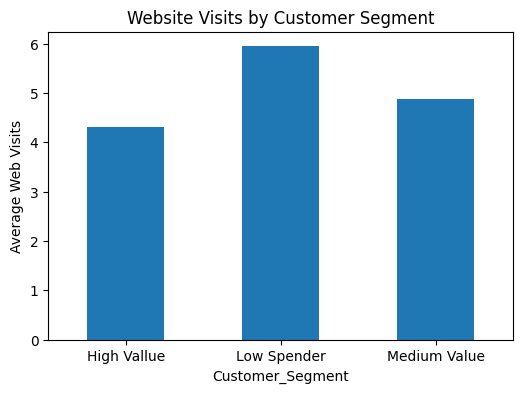

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['NumWebVisitsMonth'].mean().plot(kind='bar')

plt.title('Website Visits by Customer Segment')
plt.ylabel('Average Web Visits')
plt.xticks(rotation=0)

plt.show()

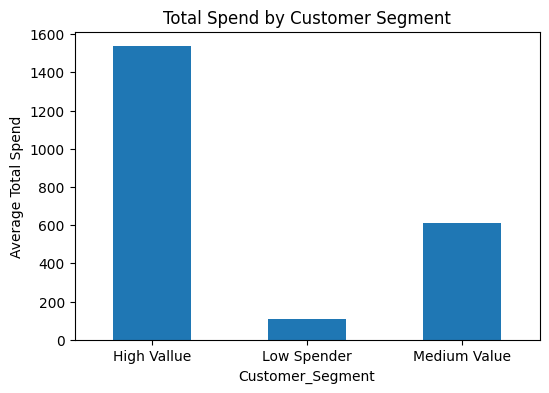

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Total_Spend'].mean().plot(kind='bar')

plt.title('Total Spend by Customer Segment')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=0)

plt.show()

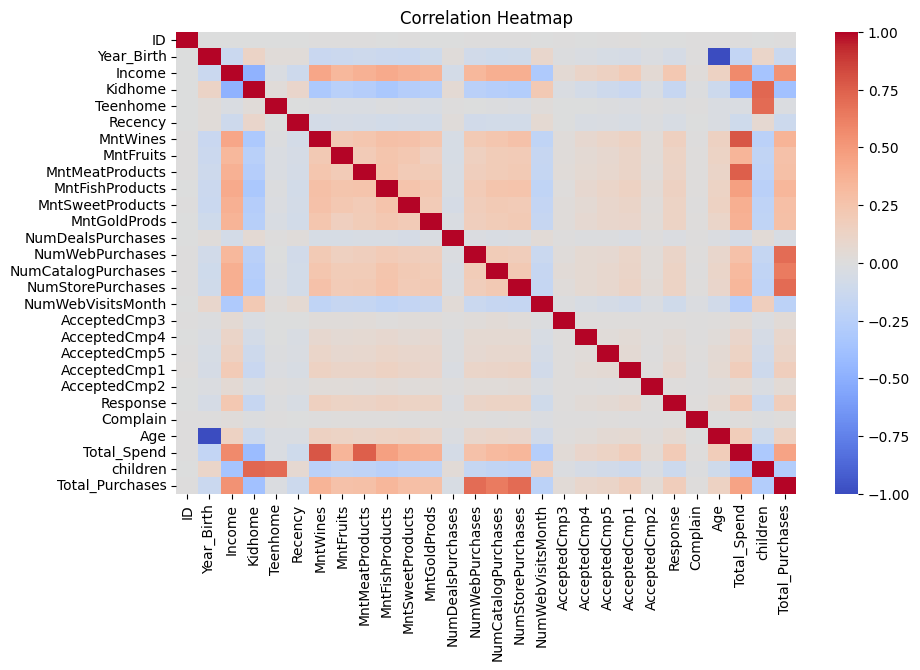

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include='number').corr(),
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# **SQL Queries for Business Insights**

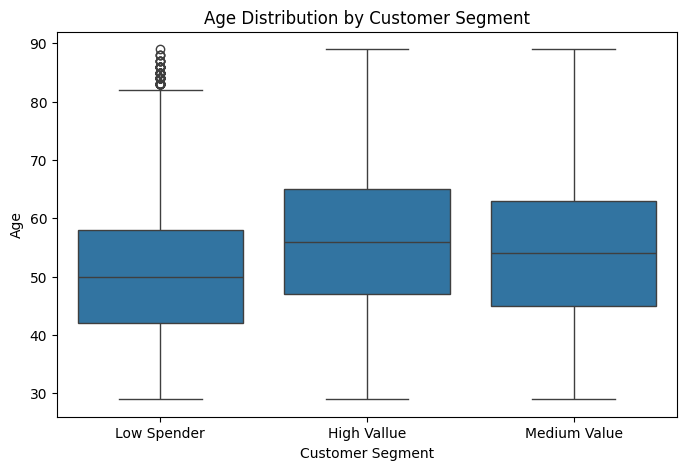

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x='Customer_Segment', y='Age', data=df)

plt.title('Age Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Age')

plt.show()

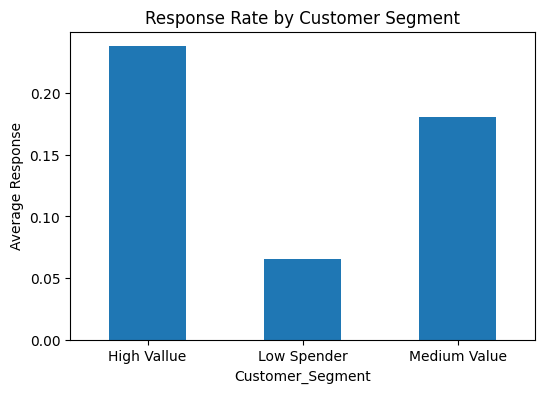

In [ ]:
plt.figure(figsize=(6,4))

df.groupby('Customer_Segment')['Response'].mean().plot(kind='bar')

plt.title('Response Rate by Customer Segment')
plt.ylabel('Average Response')
plt.xticks(rotation=0)

plt.show()

In [ ]:
import sqlite3

# Database create
conn = sqlite3.connect('marketing_campaign.db')

# DataFrame ko SQL table me save karna
df.to_sql('marketing_data', conn, if_exists='replace', index=False)

print("Database created successfully")

Database created successfully


In [ ]:
query1 = """
SELECT Customer_Segment,
       AVG(Response) AS Avg_Response_Rate
FROM marketing_data
GROUP BY Customer_Segment
ORDER BY Avg_Response_Rate DESC;
"""

result1 = pd.read_sql(query1, conn)
print(result1)

  Customer_Segment  Avg_Response_Rate
0      High Vallue           0.237851
1     Medium Value           0.180838
2      Low Spender           0.065315


In [ ]:
query2 = """
SELECT Customer_Segment,
       AVG(Total_Spend) AS Avg_Total_Spend
FROM marketing_data
GROUP BY Customer_Segment
ORDER BY Avg_Total_Spend DESC;
"""

result2 = pd.read_sql(query2, conn)
print(result2)

  Customer_Segment  Avg_Total_Spend
0      High Vallue      1535.930714
1     Medium Value       613.374143
2      Low Spender       106.238999


In [ ]:
query3 = """
SELECT
    AVG(NumWebPurchases) AS Avg_Web_Purchases,
    AVG(NumStorePurchases) AS Avg_Store_Purchases,
    AVG(NumCatalogPurchases) AS Avg_Catalog_Purchases
FROM marketing_data;
"""

result3 = pd.read_sql(query3, conn)
print(result3)

   Avg_Web_Purchases  Avg_Store_Purchases  Avg_Catalog_Purchases
0           4.248893             4.706411                2.11075


In [ ]:
query4 = """
SELECT Customer_Segment,
       AVG(Income) AS Avg_Income
FROM marketing_data
GROUP BY Customer_Segment
ORDER BY Avg_Income DESC;
"""

result4 = pd.read_sql(query4, conn)
print(result4)

  Customer_Segment    Avg_Income
0      High Vallue  81479.366169
1     Medium Value  68552.444818
2      Low Spender  33289.650030


In [ ]:
query5 = """
SELECT
    AVG(AcceptedCmp1) AS Campaign1,
    AVG(AcceptedCmp2) AS Campaign2,
    AVG(AcceptedCmp3) AS Campaign3,
    AVG(AcceptedCmp4) AS Campaign4,
    AVG(AcceptedCmp5) AS Campaign5
FROM marketing_data;
"""

result5 = pd.read_sql(query5, conn)
print(result5)

   Campaign1  Campaign2  Campaign3  Campaign4  Campaign5
0   0.134446   0.014411   0.062393   0.056821   0.045661


# **# key Insights and Conclusion**

**## Key Insights**

High Value customers have the highest average spending (≈1536) and highest income (≈81K), making them the most profitable segment.
Campaign response rate is highest among High Value customers (≈24%), while Low Spenders (≈6%) respond the least.
Store purchases (≈4.7) are the most preferred shopping channel, followed by web purchases (≈4.2). Catalog purchases are lowest.
Campaign 1 performed best with the highest acceptance rate (≈13.4%), while Campaign 2 had the lowest response.
Customers with higher income tend to spend more and respond better to campaigns.

**## Conclusion**

The analysis shows that High Value customers are the most important customer segment, as they contribute the highest spending and campaign response. The company should focus more on premium offers, loyalty programs, and personalized marketing for these customers. Since store and web channels perform best, marketing efforts should prioritize these channels. Additionally, Campaign 1 strategies can be reused, while Campaign 2 requires improvement for better engagement

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

st.title("📊 Marketing Campaign Analytics Dashboard")

# Database connect
conn = sqlite3.connect("marketing_campaign.db")

# Load data
df = pd.read_sql("SELECT * FROM marketing_data", conn)

st.subheader("Dataset Preview")
st.dataframe(df.head())

# Customer Segment Spend
st.subheader("Average Spend by Customer Segment")

spend = df.groupby("Customer_Segment")["Total_Spend"].mean()

fig, ax = plt.subplots()
spend.plot(kind="bar", ax=ax)
plt.ylabel("Average Spend")
st.pyplot(fig)

# Response Rate
st.subheader("Response Rate by Customer Segment")

response = df.groupby("Customer_Segment")["Response"].mean()

fig, ax = plt.subplots()
response.plot(kind="bar", ax=ax)
plt.ylabel("Response Rate")
st.pyplot(fig)

# Income Analysis
st.subheader("Average Income by Segment")

income = df.groupby("Customer_Segment")["Income"].mean()

fig, ax = plt.subplots()
income.plot(kind="bar", ax=ax)
plt.ylabel("Average Income")
st.pyplot(fig)

st.success("Dashboard Ready ✅")

Writing app.py


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.0 MB/s eta 0:00:00


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-06-15 16:45:32.945 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.118.243.84:8501

